In [3]:
import trimesh
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import pickle
import igl

In [7]:
import sys
from pathlib import Path
abs_path = str(Path.cwd().parents[0].absolute())
if not abs_path in sys.path:
    sys.path+=[abs_path]
print(sys.path)

['/opt/conda/lib/python310.zip', '/opt/conda/lib/python3.10', '/opt/conda/lib/python3.10/lib-dynload', '', '/opt/conda/lib/python3.10/site-packages', '/workspace/pytorch3d', '/source/sihun/NeuralFacialAnimation']


In [8]:
import numpy as np
import torch

%load_ext autoreload
%autoreload 2
from utils.exp_utils import *
from utils.remesh_utils import ICT_face_model, compute_MVC, apply_MVC_weights_batch

try:
    from matplotrender import *
except:
    !pip install git+https://github.com/chacorp/matplotrender.git
    from matplotrender import *

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [15]:
# print()
def vis_mesh(verts, faces, SIZE=4, yrot=0):
    V = normalize_homogeneous(verts) 
    print(verts.min(0), verts.max(0))
    
    model = yrotate(yrot)
    view  = translate(0, 0, -3.5)
    proj  = perspective(55, 1, 1, 100)
    MVP   = proj @ view @ model
    V = V @ MVP.T
    V /= V[:, 3].reshape(-1, 1)

    VF = V[faces]
    T = VF[:, :, :2]
    Z = -VF[:, :, 2].mean(axis=1)
    Z = (Z - Z.min()) / (Z.max() - Z.min())
    C = plt.get_cmap("magma")(Z)
    I = np.argsort(Z)

    T, C = T[I, :], C[I, :]
    fig = plt.figure(figsize=(SIZE, SIZE))
    ax = fig.add_axes([0, 0, 1, 1], xlim=[-1, 1], ylim=[-1, 1], aspect=1, frameon=False)
    collection = PolyCollection(T, closed=True, linewidth=0.1, facecolor=C, edgecolor="black")
    ax.add_collection(collection)
    plt.show()

def vis_simple(v_list, f_list, SIZE=2,mesh_scale = .8):
    # xyz Euler angle to rotate the mesh
    rot_list=[ [10,0,0] ]*len(v_list)

    plot_mesh_gouraud(v_list, f_list, mesh_scale=mesh_scale,
                     # is_diff=True, diff_base=v_list[0], #diff_revert=True,
                     rot_list=rot_list, size=SIZE, mode='shade')

In [10]:
with open("/data/sihun/pca/MF/mf_templates.pkl",'rb') as f:
    mf_templates = pickle.load(f)

pca_holder = PCA_holder(
    '/data/sihun/pca/MF/ROM/val/m--20190529--1300--002421669--GHS_pca.npz'
)
template_v = pca_holder.mean_.reshape(-1, 3)

asd = pca_holder.sample_from_pca(scale=1.0)
faces = mf_templates['face']

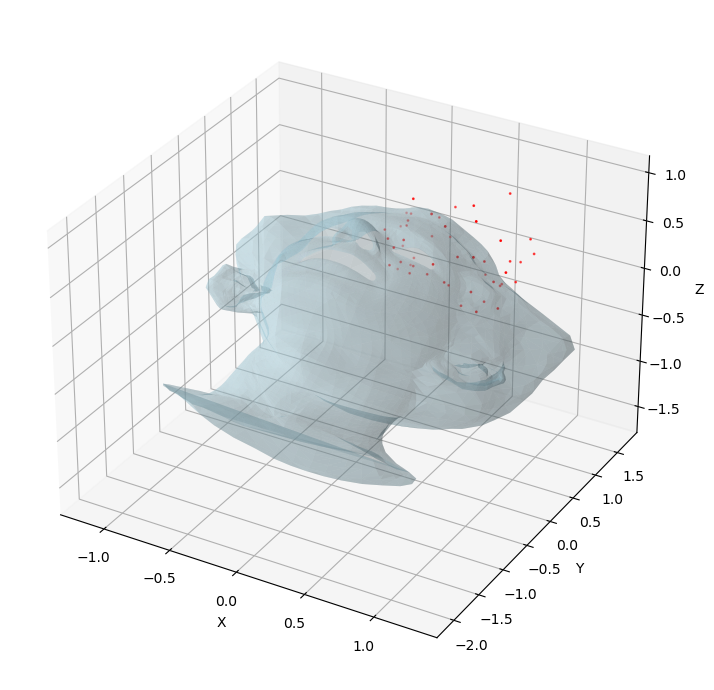

In [11]:
mesh_v = template_v

points = np.random.rand(50,3)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_trisurf(mesh_v[:, 0], mesh_v[:, 1], mesh_v[:, 2],
                triangles=faces, alpha=0.3, color='lightblue', linewidth=0.1)

ax.scatter(points[:, 0], points[:, 1], points[:, 2], color='r', s=1)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.tight_layout()
plt.show()

[-0.675 -0.25  -0.675] [0.825 0.75  0.825]


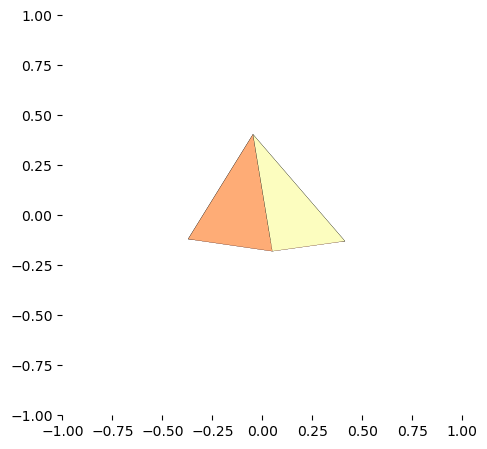

In [17]:
# large cube
cage_v = np.array([
    [0.0, 1.0, 0.0],
    [0.9, 0.0, 0.0],
    [0.0, 0.0, 0.9],
    [-0.6, 0.0, -0.6],
])
cage_f = np.array([
    [0,1,2],
    [2,1,3],
    [3,1,0],
    [0,2,3],
]).astype(int)

cage_v = cage_v - cage_v.mean(0, keepdims=True)
vis_mesh(cage_v, cage_f, yrot=10)

In [13]:

num = 512

# returns barycentric coodrinate, F index
random_points = igl.random_points_on_mesh(num, template_v, faces)
asd = template_v[faces[random_points[1]]]
asd = random_points[0][:,None,:] @ asd


m_cage_v = cage_v[None].repeat(num, 0) + asd
m_cage_f = np.concatenate([cage_f[None]+(4*(i)) for i in range(num)]).astype(int)

[-1.78887803 -2.22425641 -2.25247794] [2.03236443 2.411505   1.57307404]


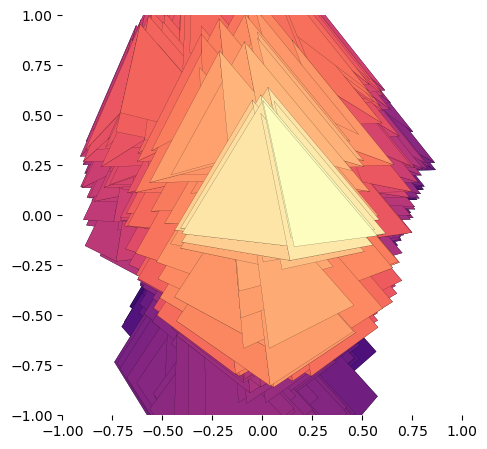

In [19]:
vis_mesh(m_cage_v.reshape(-1,3), m_cage_f.reshape(-1,3), yrot=10)